In [1]:
import numpy as np

# Data points
X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])


# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

print("X:")
print(X)

print("Y:")
print(Y)

print("A:")
print(A)

X:
[1 2 3 4 5]
Y:
[1.2 2.8 3.6 4.5 5.1]
A:
[[1. 1.]
 [2. 1.]
 [3. 1.]
 [4. 1.]
 [5. 1.]]


In [2]:
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

Slope: 0.9500000000000001, Intercept: 0.5900000000000001


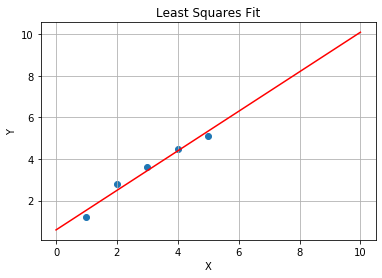

In [6]:
import matplotlib.pyplot as plt

plt.scatter(X, Y)
x = np.linspace(0, 10, 10)
y = 0.95 * x + 0.59
plt.plot(x, y, 'r')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Squares Fit")
plt.grid(True)
plt.show()

Slope: 2.5332756041539017, Intercept: 0.5748826717807846


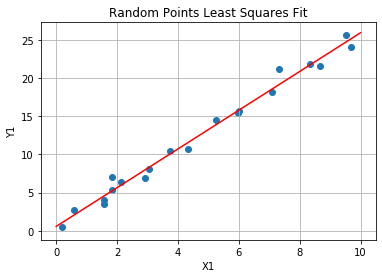

In [7]:
np.random.seed(42)

n = 20
X1 = np.sort(np.random.uniform(0, 10, n))
noise = np.random.normal(0, 1.0, n)
Y1 = 2.5 * X1 + 1.0 + noise
A1 = np.vstack([X1, np.ones(len(X1))]).T

m1, c1 = np.linalg.lstsq(A1, Y1, rcond=None)[0]
print(f"Slope: {m1}, Intercept: {c1}")

x1 = np.linspace(0, 10, 10)
y1 = m1 * x1 + c1
plt.plot(x1, y1, 'r')

plt.scatter(X1, Y1)
plt.xlabel("X1")
plt.ylabel("Y1")
plt.title("Random Points Least Squares Fit")
plt.grid(True)
plt.show()

True equation: Y = 8.6602·X + 1.5846 ± random(0,1)

Fitted equation: Y = 8.2699·X + 1.7543



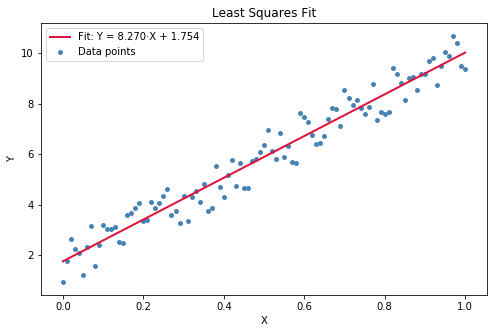

In [10]:
m_true = round(np.random.uniform(1, 10), 4)
b_true = round(np.random.uniform(0, 5),  4)
print(f"True equation: Y = {m_true}·X + {b_true} ± random(0,1)\n")

# Data points
X2 = np.arange(0, 1.01, 0.01)
Y2 = m_true * X2 + b_true + np.random.uniform(-1, 1, len(X2))

# Least Squares fit
A2 = np.vstack([X2, np.ones(len(X2))]).T
m_fit, b_fit = np.linalg.lstsq(A2, Y2, rcond=None)[0]
print(f"Fitted equation: Y = {m_fit:.4f}·X + {b_fit:.4f}\n")

# Residuals
Y2_pred = m_fit * X2 + b_fit
residuals = Y2 - Y_pred


idx_max = np.argmax(np.abs(residuals))
idx_min = np.argmin(np.abs(residuals))

plt.figure(figsize=(8, 5))
plt.scatter(X2, Y2, s=15, color="steelblue", label="Data points")
plt.plot(X2, Y2_pred, color="crimson", lw=2, label=f"Fit: Y = {m_fit:.3f}·X + {b_fit:.3f}")
plt.title("Least Squares Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()